In [1]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Sampler, BatchSampler, Dataset, DataLoader, Subset, SubsetRandomSampler, random_split
import torch.nn.functional as F
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from matplotlib import pyplot as plt
import lmfit
from scipy import interpolate
from scipy import stats
import h5py
import pandas as pd
#import tables

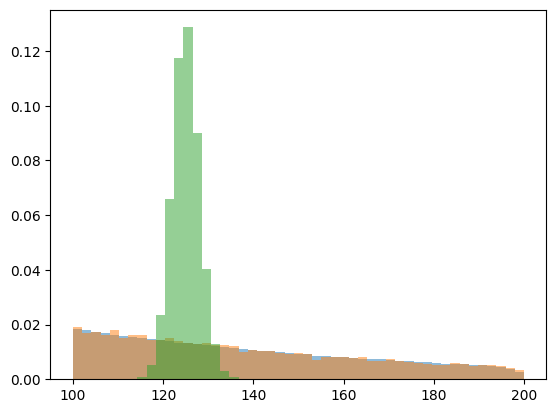

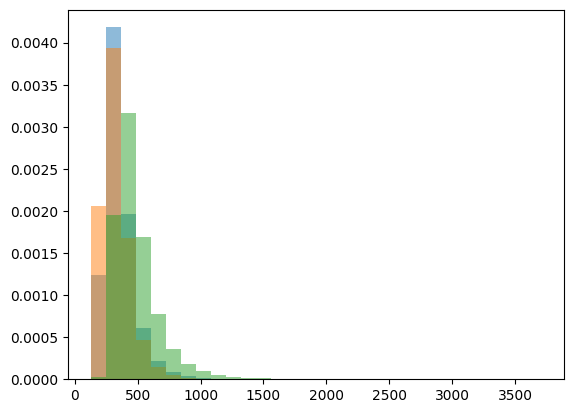

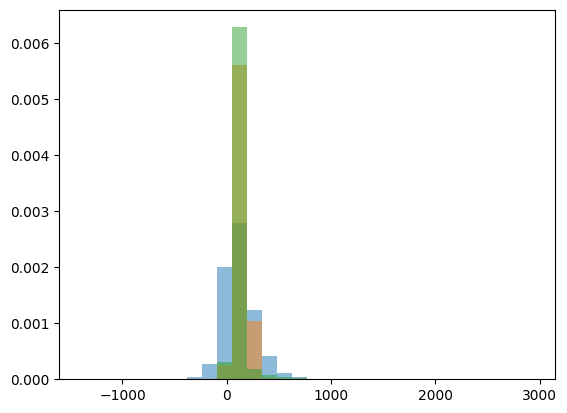

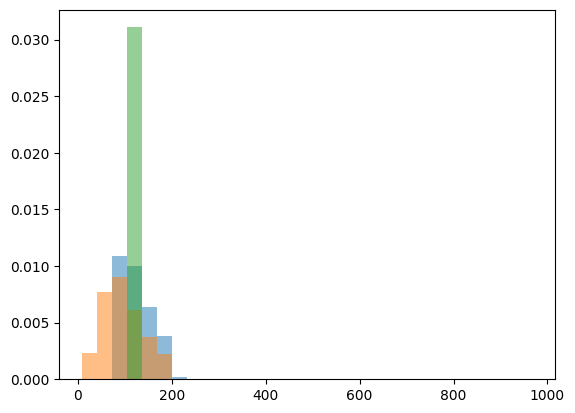

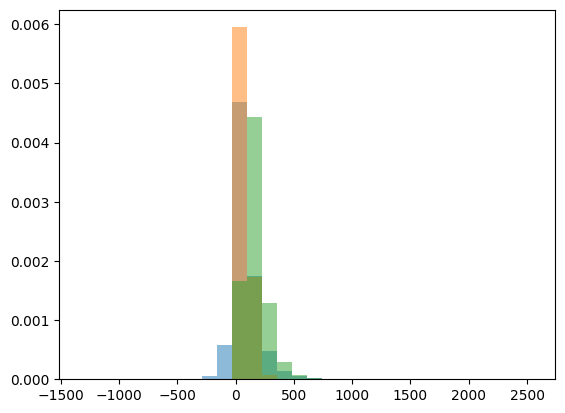

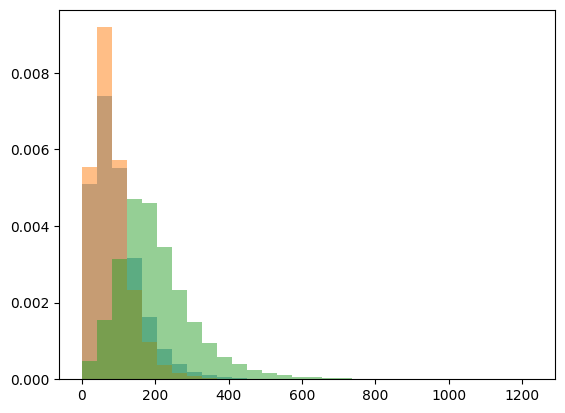

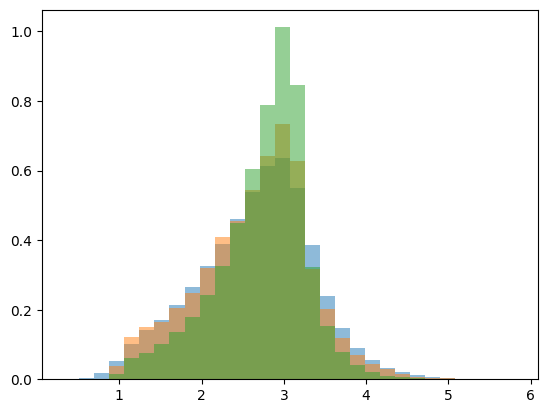

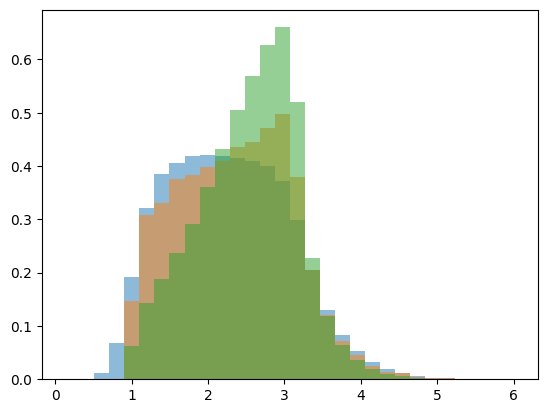

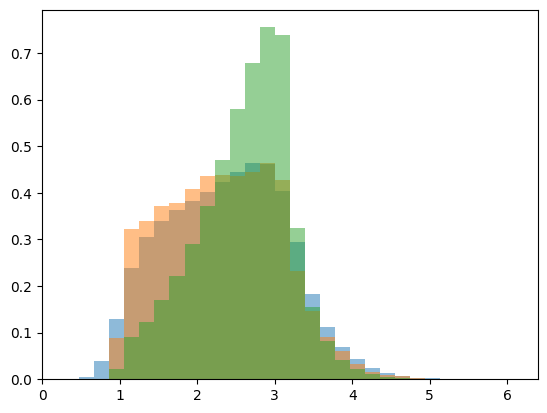

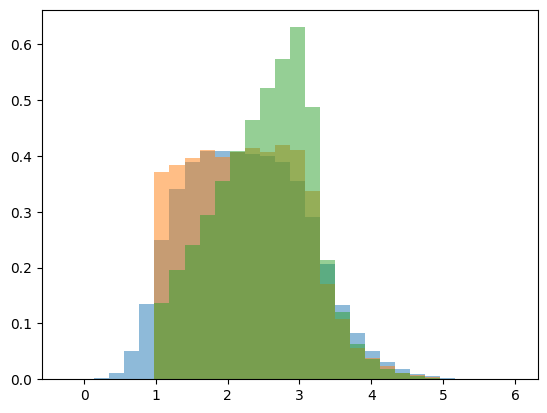

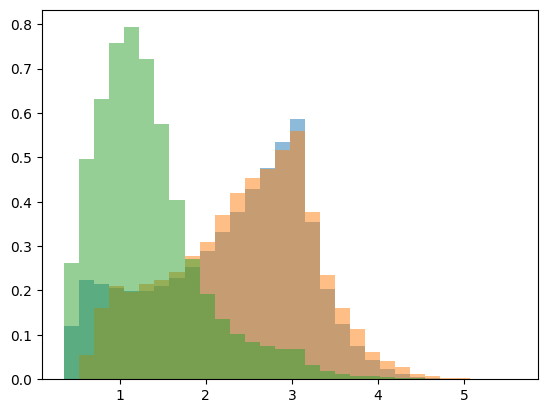

In [2]:
f_qcd0='data/bkg_bb_aa_smear.h5'
f_qcd1='data/bkg_bb_aa_v2.h5'
f_hh1='data/sm_dihiggs.h5'
f_qcd_mc = h5py.File(f_qcd0,'r')
f_qcd_da = h5py.File(f_qcd1,'r')
f_hh  = h5py.File(f_hh1,'r')
#print(f_qcd['feats'].shape,f_qcd['photons'].shape,f_qcd['bjets'].shape,f_hh['feats'].shape)
#print(f_qcd['bjets'][0,:])

bins=np.linspace(100,200,50)
plt.hist(f_qcd_mc['feats'][:,2],bins=bins,alpha=0.5,density=True)
plt.hist(f_qcd_da['feats'][:,2],bins=bins,alpha=0.5,density=True)
plt.hist(f_hh['feats'][:,2],bins=bins,alpha=0.5,density=True)
plt.show()

def convert(iData):
    cols = [f"dog_{i}" for i in range(iData.shape[1])]
    dfs = pd.DataFrame(iData, columns=cols)
    cols = ["dog_0","dog_1","dog_3","dog_4","dog_5","dog_6","dog_7","dog_8","dog_9","dog_10","dog_2"]
    dfs=dfs.reindex(columns=cols)
    return dfs
hh_data  = convert(f_hh['feats'])
qcd_data = convert(f_qcd_da['feats'])
qcd_mc   = convert(f_qcd_mc['feats'])

def plotHist(iFeat):
    counts, bin_edges, patches = plt.hist(f_qcd_mc['feats'][:,i0],bins=30,alpha=0.5,density=True)
    plt.hist(f_qcd_da['feats'][:,i0],bins=bin_edges,alpha=0.5,density=True)
    plt.hist(f_hh['feats'][:,i0],bins=bin_edges,alpha=0.5,density=True)
    plt.show()

for i0 in range(10):
    plotHist(i0)

In [214]:
class DataSet(Dataset):
    def __init__(self, samples, labels, disc):
        super(DataSet, self).__init__()
        self.labels  = labels
        self.samples = samples
        self.disc    = disc
        if len(samples) != len(labels):
            raise ValueError(
                f"should have the same number of samples({len(samples)}) as there are labels({len(labels)})")

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):
        y = self.labels[index]
        x = self.samples[index]
        z = self.disc[index]
        return x, y, z 
    
def mass(iDS): 
    e12   = np.sqrt(iDS.pxj1**2 + iDS.pyj1**2 + iDS.pzj1**2 + iDS.mj1**2)
    e22   = np.sqrt(iDS.pxj2**2 + iDS.pyj2**2 + iDS.pzj2**2 + iDS.mj2**2)
    etot  = e12 + e22
    pxtot = iDS.pxj1 + iDS.pxj2
    pytot = iDS.pyj1 + iDS.pyj2
    pztot = iDS.pzj1 + iDS.pzj2
    return np.sqrt(etot**2 - pxtot**2 - pytot**2 - pztot**2)

def makeNP(iDS):
    massvals=mass(iDS)
    tmp=iDS[["mj1","tau1j1","tau2j1","tau3j1","mj2","tau1j2","tau2j2","tau3j2"]].to_numpy()
    massvals=np.reshape(massvals,(len(massvals),1))
    tmp=np.hstack((tmp,massvals))
    print(len(tmp))
    return tmp

def makeDataSet(iD,iNS,iNB):
    pD    = torch.from_numpy(iD)
    discs = torch.cat((torch.ones(iNS), torch.zeros(iNB)))
    rand  = torch.randperm(len(pD))
    pXD   = pD[rand]
    tot   = pXD[:,:-1].float()   #this is our discriminator we want to learn
    label = pXD[:,-1].float()  ####Note this is a regression, so we want to put y=f(x)
    xdisc = discs[rand]
    datatrain=DataSet(samples=tot,labels=label, disc=xdisc)
    bkgdatatrain=DataSet(samples=pD[iNS:,:-1].float(),labels=pD[iNS:,-1].float(),disc=torch.zeros(iNB))
    return datatrain,bkgdatatrain,pD[0:iNS].float(),pD[iNS:].float()

def plotSigBkg(iN,sig,bkg,nbins=50):
    tot=torch.cat((sig,bkg))
    for pVar in range(iN+2):
        xmin=torch.min(bkg[:,pVar])
        xmax=torch.max(bkg[:,pVar])
        binrange=np.arange(xmin,xmax,(xmax-xmin)/nbins)
        plt.hist(sig[:,pVar],bins=binrange,density=True,alpha=0.5,label='sig')
        plt.hist(bkg[:,pVar],bins=binrange,density=True,alpha=0.5,label='bkg')
        plt.hist(tot[:,pVar],bins=binrange,density=True,alpha=0.5,label='tot')
        plt.legend()
        plt.show()

def setupData(iParr1,iParr2,iNB,iNS,iStart=0,iSStart=0):
    nparr1=iParr1[iStart:(iStart+iNB)]
    nparr2=iParr2[iSStart:(iSStart+iNS)]
    nparr1_norm = nparr1.copy()
    nparr2_norm = nparr2.copy()
    #nparr1_norm.iloc[:, :-1] = (nparr1.iloc[:,:-1] - nparr1.iloc[:, :-1].mean()) / nparr1.iloc[:, :-1].std()
    #nparr2_norm.iloc[:, :-1] = (nparr2.iloc[:,:-1] - nparr1.iloc[:, :-1].mean()) / nparr1.iloc[:, :-1].std()
    pdata = np.vstack((nparr2_norm,nparr1_norm))
    data,bkgdata,test_sig,test_bkg=makeDataSet(pdata,len(nparr2),len(nparr1))
    #plotSigBkg(9,test_sig,test_bkg)
    
    return data,bkgdata,test_sig,test_bkg
dataset,mcdataset,sig,bkg    =setupData(qcd_data,hh_data,7000,40) #3ab yield
dataset2,mcdataset2,sig2,bkg2=setupData(qcd_mc  ,hh_data,20000,20000,10000,1000)
dataset3,mcdataset3,sig3,bkg3=setupData(qcd_data,hh_data,20000,20000,8000,1000)
dataset4,mcdataset4,sig4,bkg4=setupData(qcd_data,hh_data,10000,10000,20000,22000)
print(len(dataset),len(dataset2))

7040 40000


In [117]:
%load_ext autoreload
%autoreload 2
from splitfitter import simple_MLPFit_lmfit,fitGausLin,fitGausPowLaw,fitGausFlat,fitGausDijet,fitGausBern,plotPerf,plotCheck

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [309]:
model_basic = simple_MLPFit_lmfit(dataset,10,k_fold=1,nhidden=32,out_channels=1,act_out=False,n_epochs=10,fit_opt=2,bkg_loss=1.0,iFitPFunc=fitGausBern(),iFitFFunc=fitGausBern(),
                                massDeco=0.,mc_data=dataset4,bkgPressure=False,lambScale=0.0,batch_size=7040,lambvar=0.)
model_basic.pretrain(dataset2,5000,101)
#model_basic.train(51)


Epoch: 0 LOSS train: 306.2938232421875 
Epoch: 10 LOSS train: 8.867622375488281 
Epoch: 20 LOSS train: 4.151581764221191 
Epoch: 30 LOSS train: 3.6384952068328857 
Epoch: 40 LOSS train: 3.4303481578826904 
Epoch: 50 LOSS train: 3.1979119777679443 
Epoch: 60 LOSS train: 3.068873882293701 
Epoch: 70 LOSS train: 2.918198823928833 
Epoch: 80 LOSS train: 2.797713279724121 
Epoch: 90 LOSS train: 2.697498321533203 
Epoch: 100 LOSS train: 2.6380555629730225 
Checkpoint saved to checkpoint_2_dpout.pth


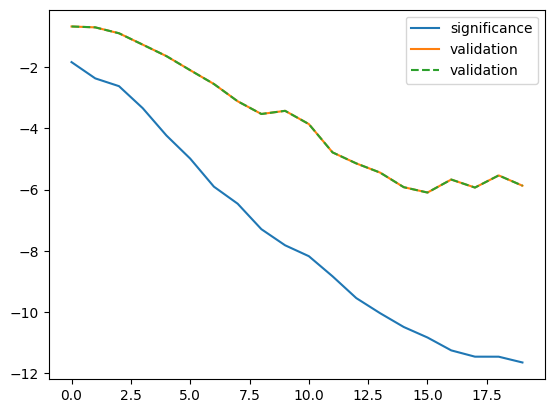

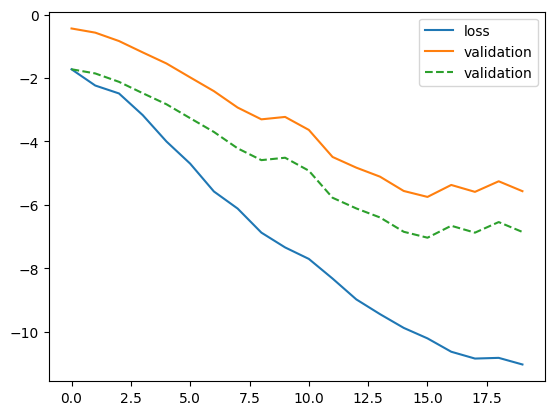

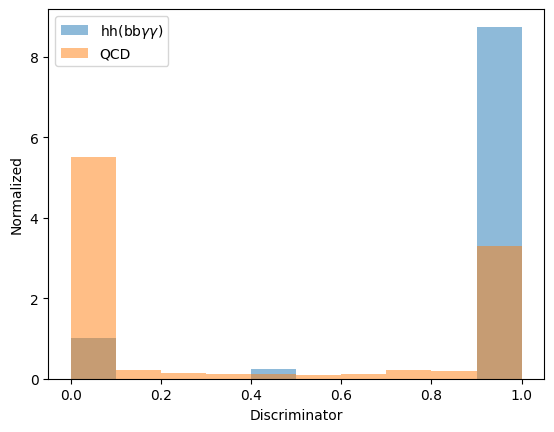

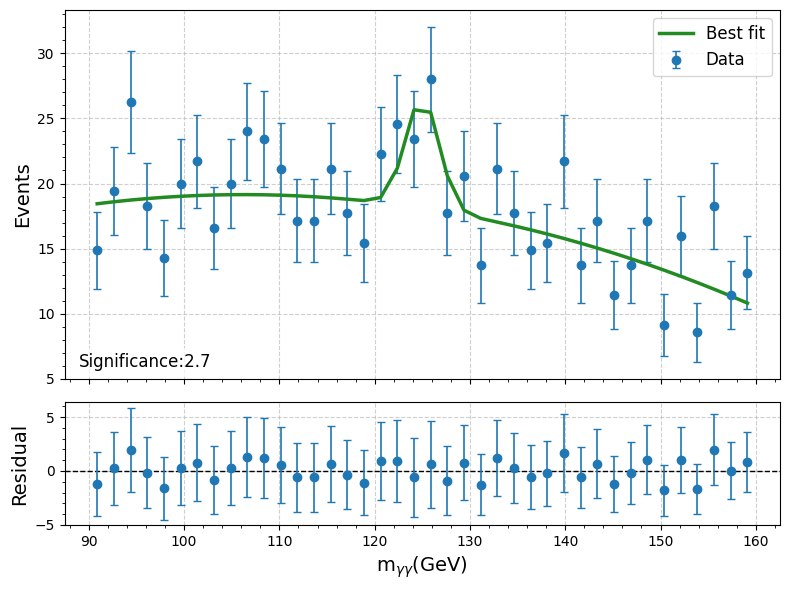

[[Model]]
    Model(funcSig_np)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 16
    # data points      = 40
    # variables        = 4
    chi-square         = 39.7809765
    reduced chi-square = 1.10502713
    Akaike info crit   = 7.78037471
    Bayesian info crit = 14.5358925
    R-squared          = 0.94948984
[[Variables]]
    par0: -14.4647429 +/- 23.3024428 (161.10%) (init = 50)
    par1:  8.44698746 +/- 3.26561930 (38.66%) (init = 50)
    par2:  125 (fixed)
    par3:  2.5 (fixed)
    par4:  0.63281639 +/- 0.37907494 (59.90%) (init = 0)
    par5: -0.00297850 +/- 0.00150380 (50.49%) (init = 0)
[[Correlations]] (unreported correlations are < 0.100)
    C(par4, par5) = -0.998
    C(par0, par4) = -0.997
    C(par0, par5) = 0.990
    C(par1, par5) = 0.317
    C(par1, par4) = -0.314
    C(par0, par1) = 0.304


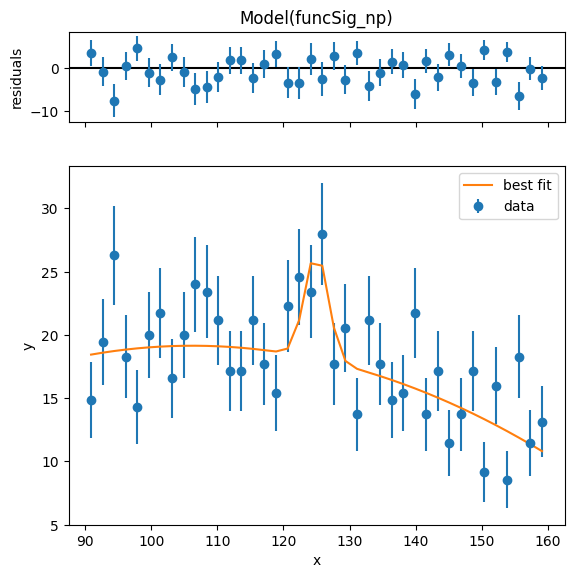

Pass Significance: 5.87162719417617


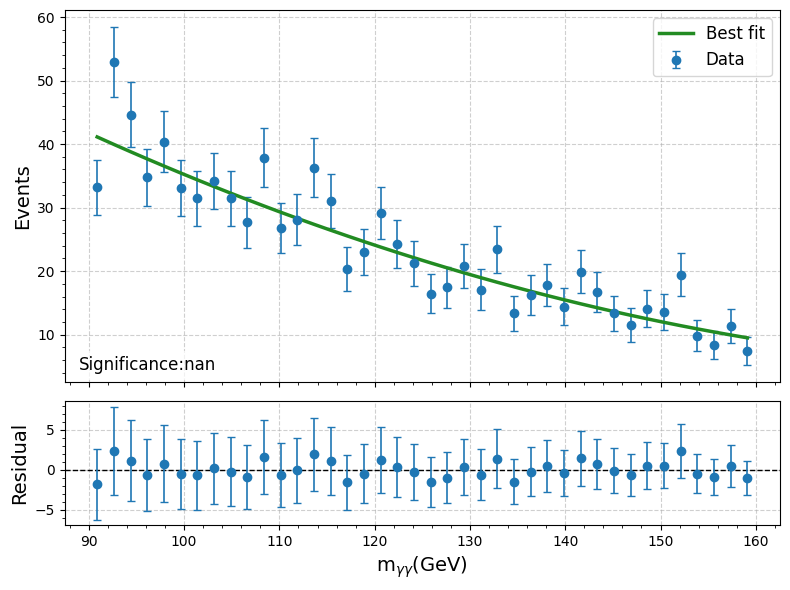

[[Model]]
    Model(funcSig_np)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 212
    # data points      = 40
    # variables        = 4
    chi-square         = 45.1638474
    reduced chi-square = 1.25455132
    Akaike info crit   = 12.8566991
    Bayesian info crit = 19.6122169
    R-squared          = 0.98976841
##  Warning: uncertainties could not be estimated:
[[Variables]]
    par0:  128.084888 (init = 50)
    par1:  3.6194e-08 (init = 50)
    par2:  125 (fixed)
    par3:  2.5 (fixed)
    par4: -1.23882089 (init = 0)
    par5:  0.00310167 (init = 0)
Fail Significance: -3.968382600305631e-08
Bkg Significance: 1.4724864805868947


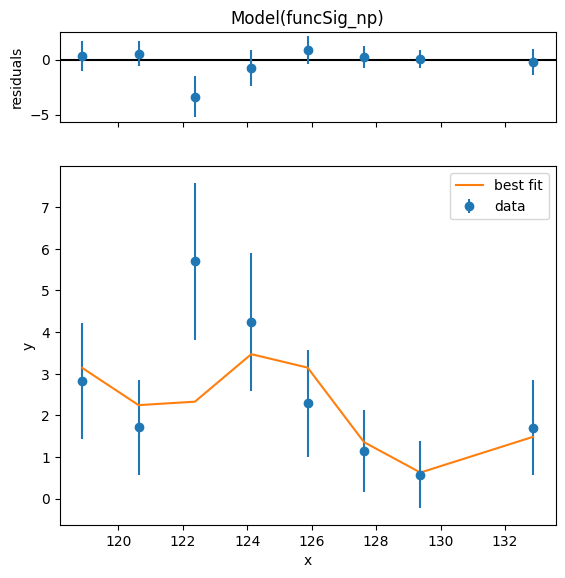

In [315]:
from splitfitter import plotLoss,plotSigs

dummydataset,mcdataset,sig,bkg        =setupData(qcd_data,hh_data,7000,40,7000,8900)
dummydataset2,mcdataset2,dsig,dbkg    =setupData(qcd_data,hh_data,7000,40,4000,22900)
model_basic.otlossdiff = 100
model_basic.bkg_loss = 1.0
model_basic.massDeco = 0.0
model_basic.delta_sys = 1.0
model_basic.round = False
model_basic.reloadData(dummydataset,iMC=dummydataset2)
model_basic.train(20,iLoad=True)
plotSigs(model_basic)
plotLoss(model_basic)
plotPerf(dsig,dbkg,model_basic)
#plotPerf(dsig,dbkg,model_basic)


toy: 0
toy: 1
toy: 2
toy: 3
toy: 4
toy: 5
toy: 6
toy: 7
toy: 8
toy: 9
toy: 10
toy: 11
toy: 12
toy: 13
toy: 14
toy: 15
toy: 16
toy: 17
toy: 18
toy: 19
toy: 20
toy: 21
toy: 22
toy: 23
toy: 24
toy: 25
toy: 26
toy: 27
toy: 28
toy: 29
toy: 30
toy: 31
toy: 32
toy: 33
toy: 34
toy: 35
toy: 36
toy: 37
toy: 38
toy: 39
toy: 40
toy: 41
toy: 42
toy: 43
toy: 44
toy: 45
toy: 46
toy: 47
toy: 48
toy: 49
toy: 50
toy: 51
toy: 52
toy: 53
toy: 54
toy: 55
toy: 56
toy: 57
toy: 58
toy: 59
toy: 60
toy: 61
toy: 62
toy: 63
toy: 64
toy: 65
toy: 66
toy: 67
toy: 68
toy: 69
toy: 70
toy: 71
toy: 72
toy: 73
toy: 74
toy: 75
toy: 76
toy: 77
toy: 78
toy: 79
toy: 80
toy: 81
toy: 82
toy: 83
toy: 84
toy: 85
toy: 86
toy: 87
toy: 88
toy: 89
toy: 90
toy: 91
toy: 92
toy: 93
toy: 94
toy: 95
toy: 96
toy: 97
toy: 98
toy: 99
Z-score: 1.75068607125217 p-value: 0.04 - 2.5207876420158035 0.05977442963281615


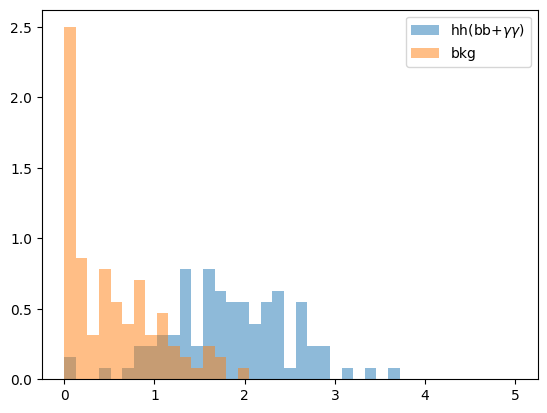

Z-score: 2.3263478740408408 p-value: 0.01 - 3.2847532615366792 0.13323415619795115


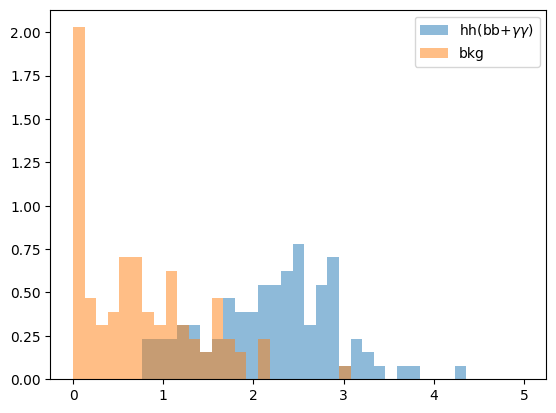

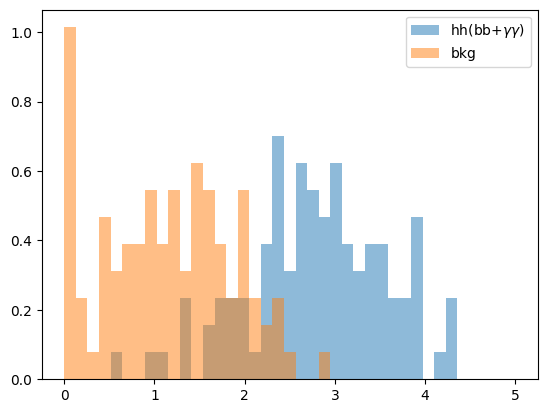

sig2_lbk1_10lr5e5_dpout_v5_spf_toys_space.npz


In [217]:
from splitfitter import trainToys
#
trainToys(sig3,bkg3,model_basic,40,7000,100,"sig2_lbk1_10lr5e5_dpout_v5")

In [212]:
from splitfitter import plotPerfToys

#plotPerf(sig,bkg,model_basic)
plotPerfToys(sig4,bkg4,model_basic,-1,40,7000,1000,iLabel="spf_sup_toys_space_disc_base_34_v5")

toy: 0
40 7000 !
40 7000 !


ValueError: Cannot take a larger sample than population when 'replace=False'

tensor(1., grad_fn=<MaxBackward1>) tensor(3.8315e-17, grad_fn=<MinBackward1>)
torch.Size([7040]) torch.Size([7040, 1])


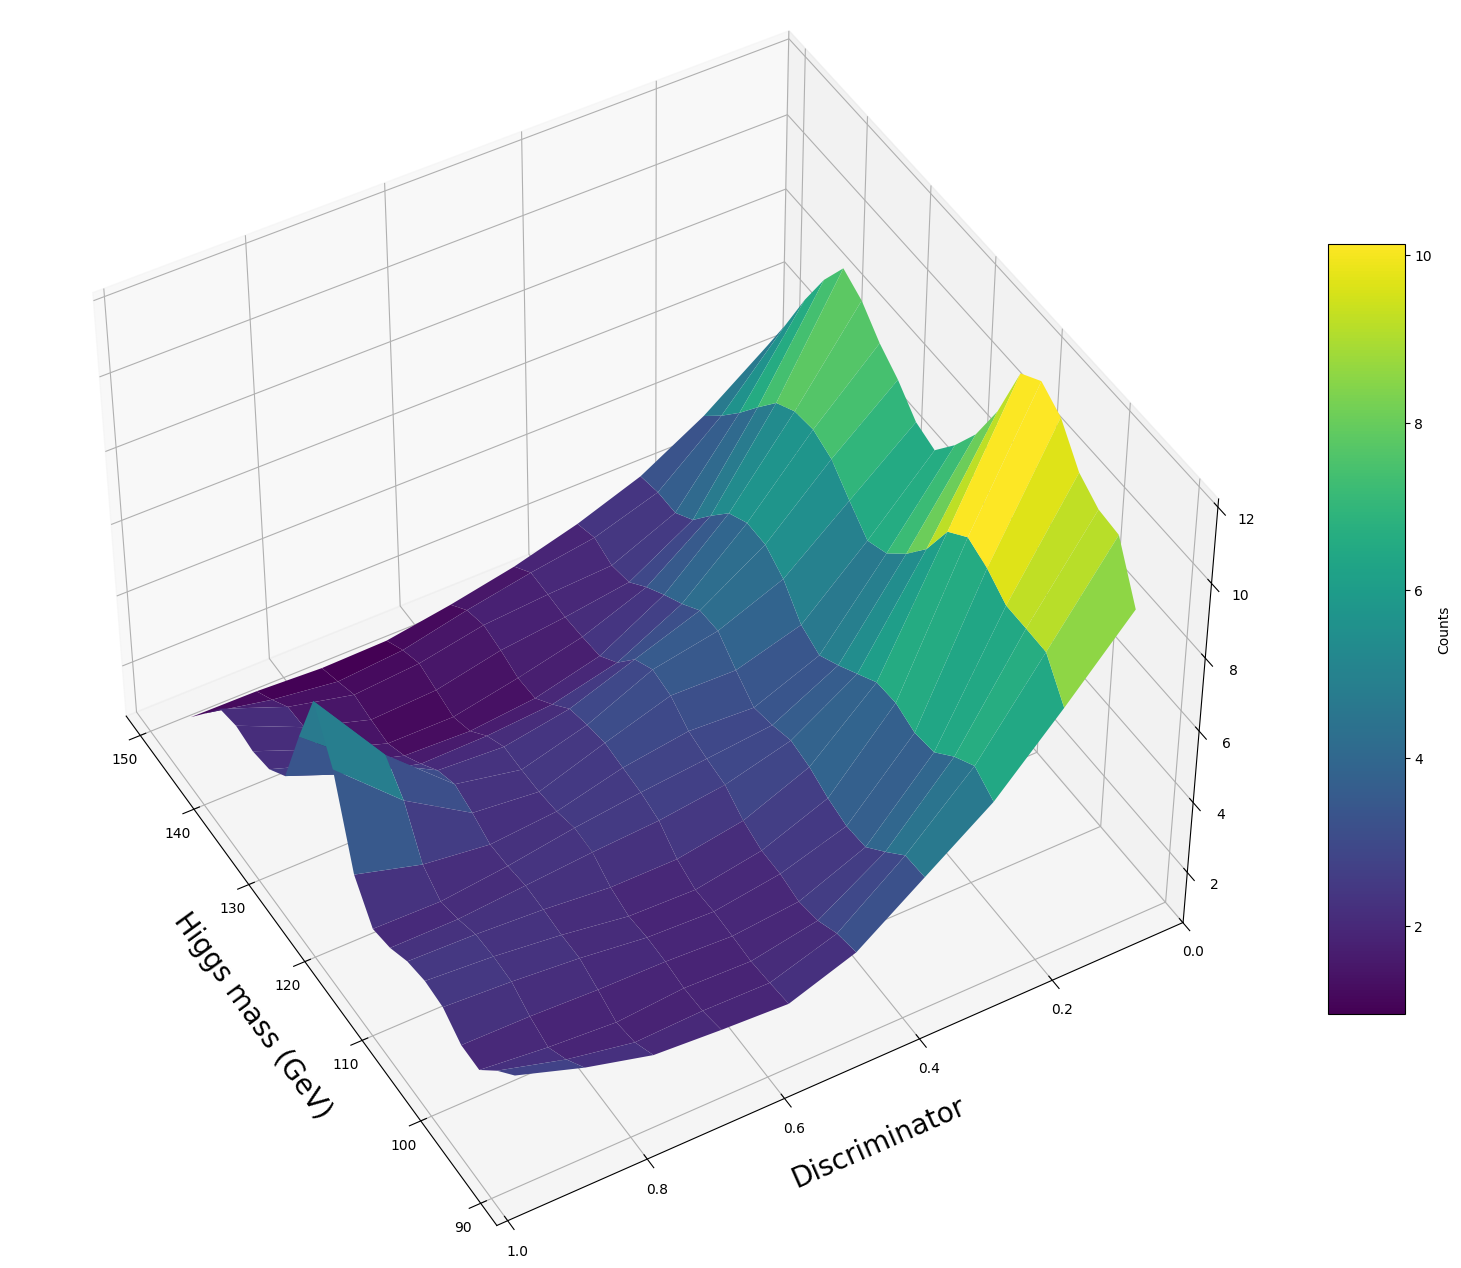

In [23]:
from splitfitter import plot3D

plot3D(sig,bkg,model_basic)